# 5. Análisis unidimensional (sección 2.2)

*Autores: María Carolina Cantillo Orozco (200179105) y Juan Camilo Oñoro Araujo (200177329)*

Para cada variable: tipo y cardinalidad, estadísticos (media, mediana,
desviación, percentiles), distribución, asimetría y curtosis, normalidad,
outliers, y para las categóricas frecuencias, categorías raras y su
tratamiento. Las lecturas de asimetría y curtosis siguen las tablas de las
notas de clase (9.1.1):

| \|asimetría\| | lectura | | \|curtosis\| (Fisher) | lectura |
|---|---|---|---|---|
| < 0.5 | aprox. simétrica | | < 0.5 | similar a la normal |
| 0.5 – 1 | moderadamente asimétrica | | 0.5 – 1 | moderada |
| > 1 | altamente asimétrica | | > 1 | fuerte |

In [1]:
# Celda de preparación: rutas, librerías, estilo de figuras y carga de datos.
# Todo el EDA se hace SOLO con la partición de entrenamiento: mirar test aquí
# filtraría información a las decisiones de preprocesamiento (fuga de datos).
import sys
import warnings
from pathlib import Path

# Si el notebook se ejecuta desde notebooks/, la raíz del libro es la carpeta
# padre; se añade al path para poder importar el paquete src.
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))
# Los FutureWarning de pandas/seaborn no afectan los resultados; se silencian
# para que el libro quede legible.
warnings.filterwarnings("ignore", category=FutureWarning)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

from src import config as C
from src import estadistica as E
from src import graficos as G
from src import particion as P

G.estilo()  # estilo común del libro (fuentes grandes para legibilidad)
C.aviso_sintetico()  # avisa en grande si se está usando el CSV sintético de prueba
# Formato de salida: 3 decimales con separador de miles y más columnas visibles.
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
pd.set_option("display.max_columns", 30)
# Solo train: la partición por bloques espaciales ya se hizo en capítulos previos.
train = P.cargar_particion(solo="train")
# Listas de variables definidas en config, filtradas a las que existen en los datos.
nums = [c for c in C.NUMERICAS if c in train]
cats = [c for c in C.CATEGORICAS if c in train]

## 5.1 Tipo de variable y cardinalidad

In [2]:
# Tabla de tipos: dtype real, tipo conceptual, número de valores distintos y
# porcentaje de nulos. La cardinalidad orienta el tratamiento (p. ej. conteos
# con pocos valores distintos se grafican como barras; categóricas con muchas
# categorías pueden requerir agrupar las raras antes del one-hot).
tipos = pd.DataFrame({
    "dtype": [str(train[c].dtype) for c in nums + cats + C.ESPACIALES],
    # Las coordenadas se separan como "numérica (espacial)" porque se analizan
    # aparte (cap. 8) y su papel en el modelo es distinto al de las físicas.
    "tipo": ["numérica"] * len(nums) + ["categórica"] * len(cats) + ["numérica (espacial)"] * len(C.ESPACIALES),
    "valores distintos": [train[c].nunique() for c in nums + cats + C.ESPACIALES],
    "% nulos": [100 * train[c].isna().mean() for c in nums + cats + C.ESPACIALES],
}, index=nums + cats + C.ESPACIALES)
tipos

,dtype,tipo,valores distintos,% nulos
area_construida,float64,numérica,7489,0.000
area_catastral_terreno,float64,numérica,20016,0.000
total_habitaciones,float64,numérica,21,0.124
total_banios,float64,numérica,16,0.013
total_plantas,float64,numérica,16,0.000
antiguedad,float64,numérica,76,0.059
planta_ubicacion,float64,numérica,41,0.108
altura,float64,numérica,5,0.000
tipo_vivienda,object,categórica,4,0.000
uso,object,categórica,6,0.000


## 5.2 Variables numéricas: estadísticos

In [3]:
# Estadísticos descriptivos de las numéricas (físicas y espaciales).
# E.resumen_numerico calcula, sobre los valores no nulos, media, mediana,
# desviación, percentiles, IQR, asimetría y curtosis (Fisher: normal = 0),
# outliers por la regla de Tukey (fuera de Q1 − 1.5·IQR, Q3 + 1.5·IQR) y la
# lectura de asimetría y curtosis según las tablas de las notas de clase.
resumen = E.resumen_numerico(train, nums + C.ESPACIALES)
# Primera vista: posición y dispersión. Comparar media con mediana y p99 con
# max revela colas largas (la media se desplaza hacia la cola).
resumen[["n", "% nulos", "media", "mediana", "desv_est", "min", "p5", "p25", "p75", "p95", "p99", "max"]]

,n,% nulos,media,mediana,desv_est,min,p5,p25,p75,p95,p99,max
variable,,,,,,,,,,,,
area_construida,218870,0.000,96.452,76.000,71.265,10.000,38.000,54.000,115.000,221.000,372.000,"1,971.000"
area_catastral_terreno,218870,0.000,117.279,71.300,415.408,0.000,18.490,30.600,144.500,311.800,524.000,"36,022.000"
total_habitaciones,218599,0.124,2.889,3.000,1.081,0.000,2.000,2.000,3.000,4.000,6.000,20.000
total_banios,218842,0.013,1.620,1.000,0.885,0.000,1.000,1.000,2.000,3.000,5.000,15.000
total_plantas,218869,0.000,1.167,1.000,0.731,1.000,1.000,1.000,1.000,2.000,4.000,35.000
antiguedad,218741,0.059,19.031,16.000,14.174,0.000,3.000,8.000,28.000,40.000,74.000,94.000
planta_ubicacion,218633,0.108,2.864,1.000,3.165,1.000,1.000,1.000,4.000,10.000,14.000,41.000
altura,218870,0.000,2.994,3.000,0.115,1.000,3.000,3.000,3.000,3.000,3.000,9.000
x_km,218870,0.000,-4.411,-4.199,2.316,-13.077,-8.090,-6.011,-2.554,-1.287,-0.101,1.595


In [4]:
# Segunda vista: forma de la distribución. Asimetría y curtosis con su lectura
# (|asimetría| > 1 = altamente asimétrica) y el número y % de outliers de
# Tukey, que en distribuciones con cola larga suele ser alto sin que haya
# errores: la regla de Tukey supone aproximadamente simetría.
resumen[["asimetría", "lectura_asimetría", "curtosis", "lectura_curtosis", "outliers_Tukey", "% outliers"]]

,asimetría,lectura_asimetría,curtosis,lectura_curtosis,outliers_Tukey,% outliers
variable,,,,,,
area_construida,3.964,altamente asimétrica,34.096,"fuerte, leptocúrtica (colas pesadas)",13073,5.973
area_catastral_terreno,51.673,altamente asimétrica,"3,401.789","fuerte, leptocúrtica (colas pesadas)",10579,4.833
total_habitaciones,2.339,altamente asimétrica,17.817,"fuerte, leptocúrtica (colas pesadas)",12238,5.598
total_banios,1.699,altamente asimétrica,7.648,"fuerte, leptocúrtica (colas pesadas)",7320,3.345
total_plantas,10.181,altamente asimétrica,147.564,"fuerte, leptocúrtica (colas pesadas)",24390,11.144
antiguedad,1.320,altamente asimétrica,2.913,"fuerte, leptocúrtica (colas pesadas)",3018,1.380
planta_ubicacion,2.291,altamente asimétrica,6.739,"fuerte, leptocúrtica (colas pesadas)",17447,7.980
altura,-9.952,altamente asimétrica,496.062,"fuerte, leptocúrtica (colas pesadas)",683,0.312
x_km,-0.452,aprox. simétrica,-0.180,similar a la normal,669,0.306


## 5.3 Distribuciones

Histogramas en escala original y en escala `log1p` (las áreas y conteos
tienen colas largas: en escala original la mayor parte del histograma queda
aplastada contra el cero).

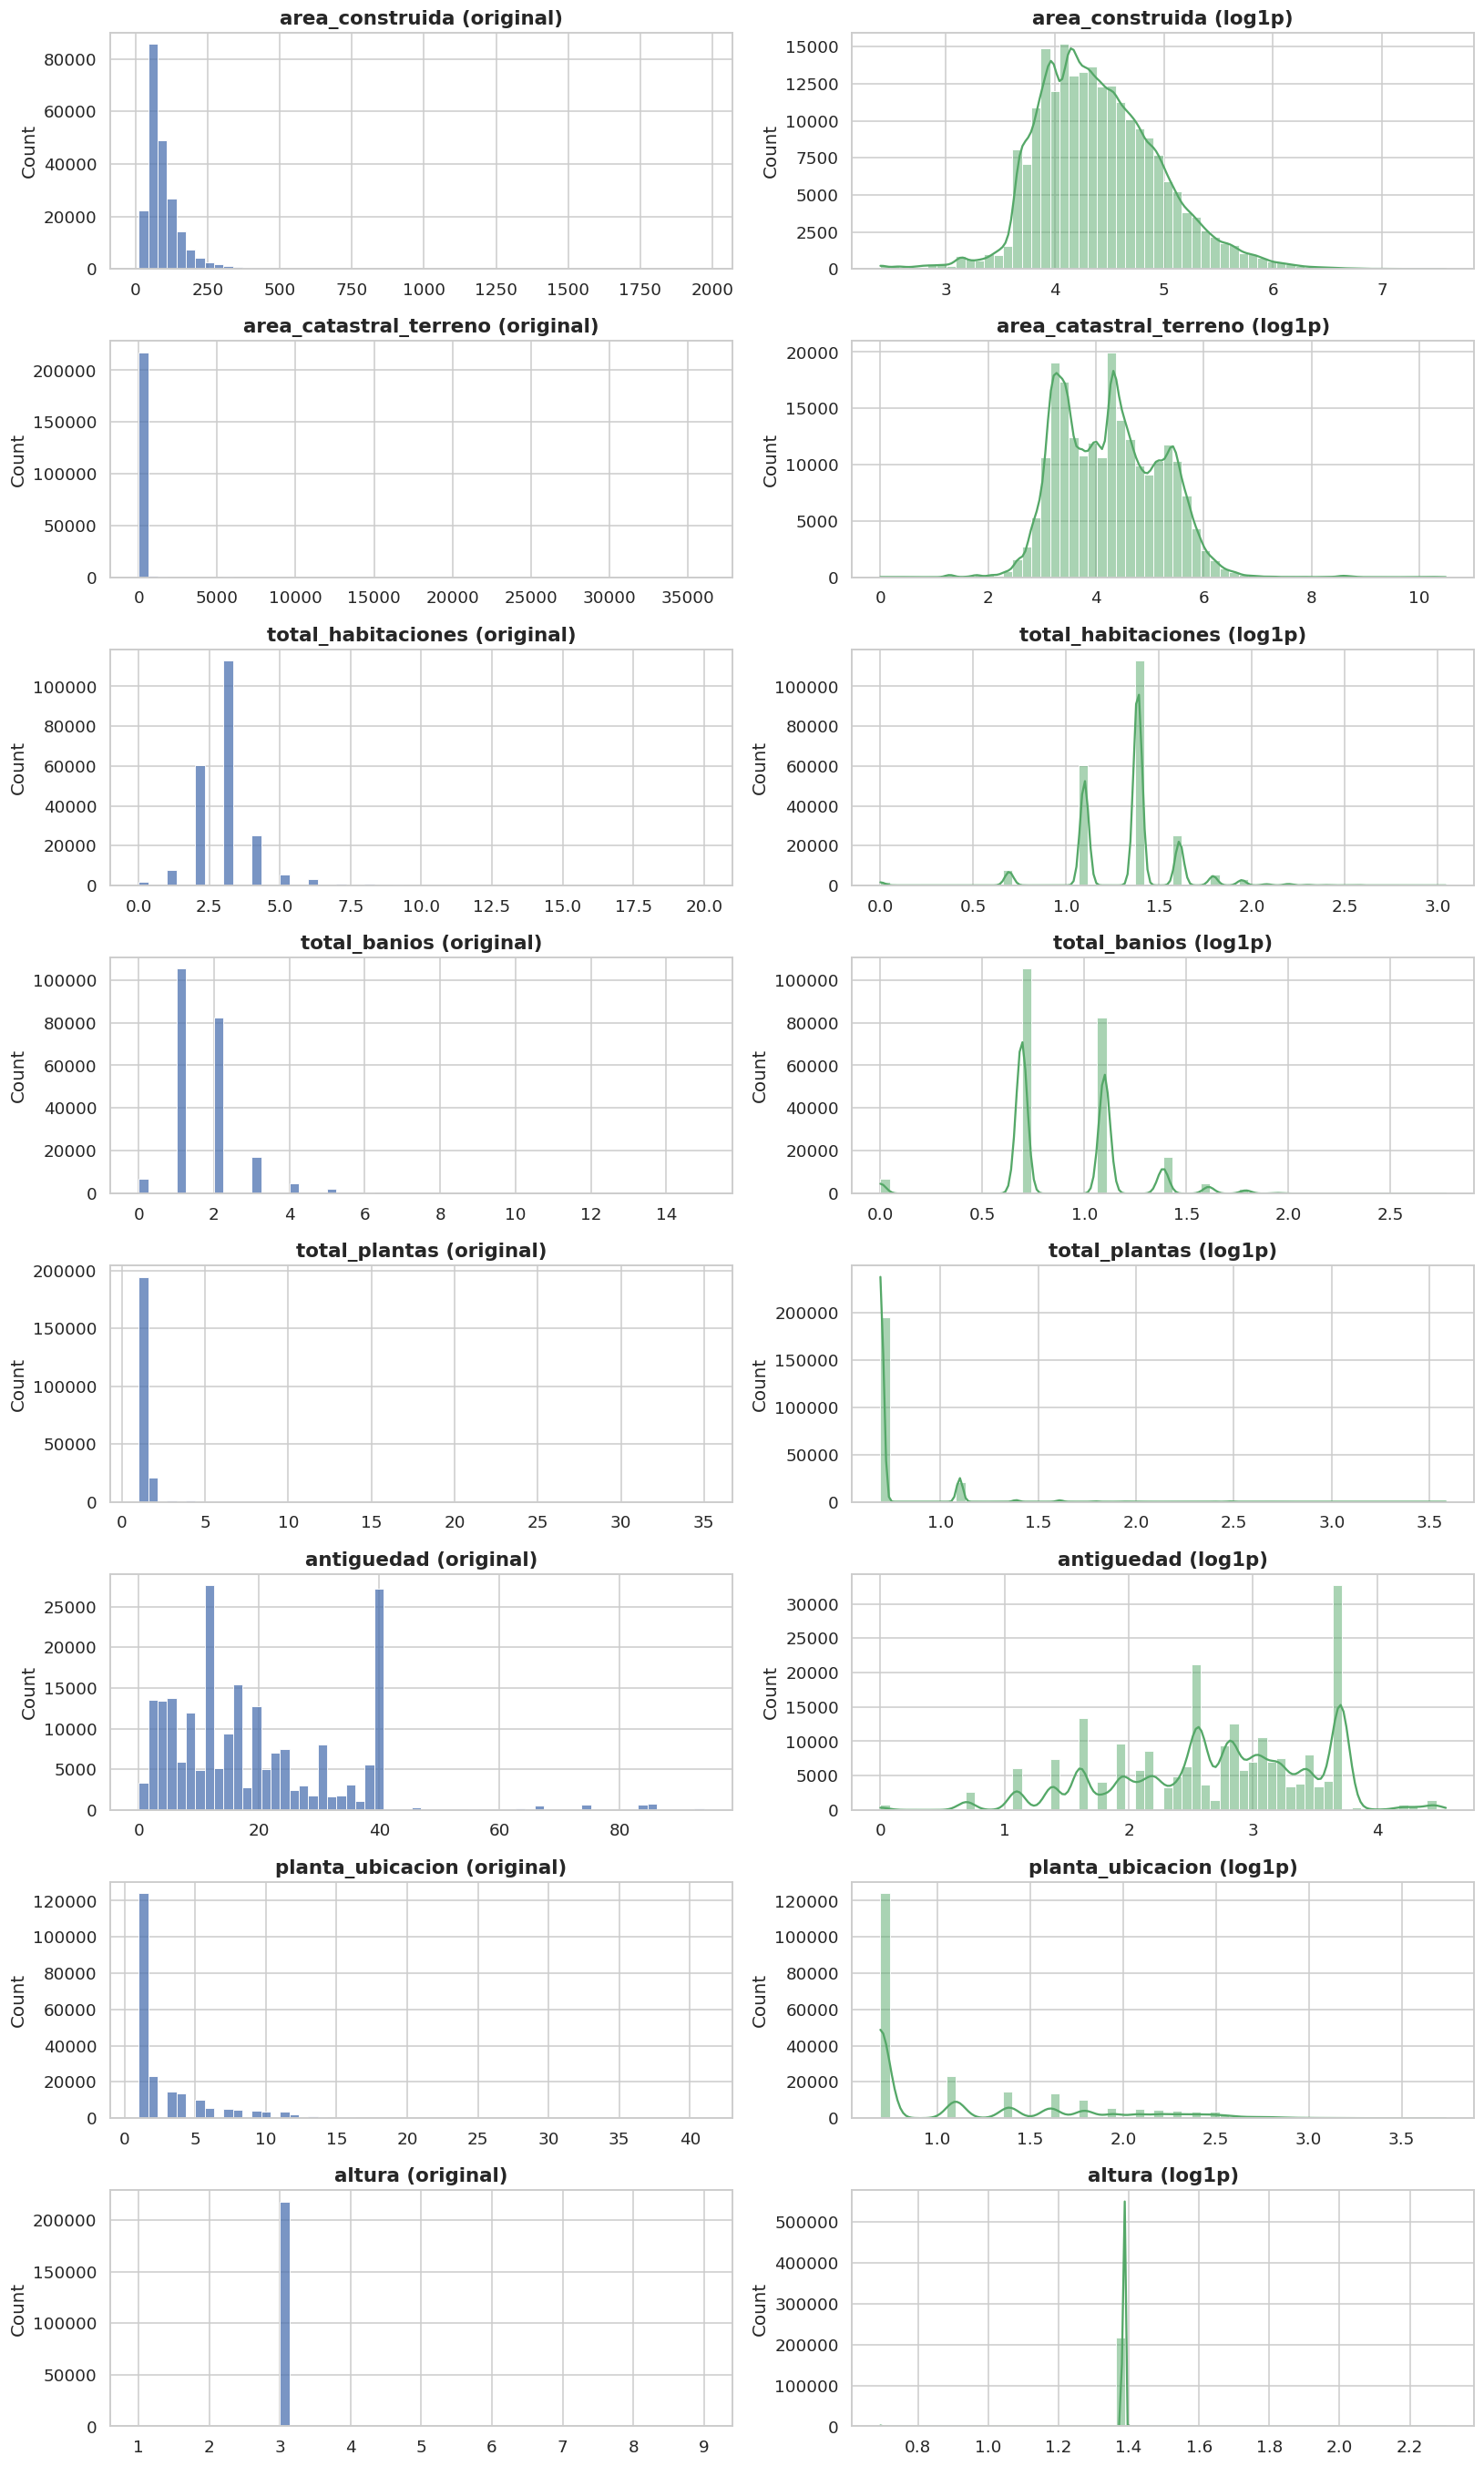

In [5]:
# Figura: una fila por variable numérica; a la izquierda el histograma en
# escala original (azul) y a la derecha en escala log1p (verde, con KDE).
# Permite ver visualmente si la transformación logarítmica "abre" la cola.
fig, axes = plt.subplots(len(nums), 2, figsize=(15, 3.1 * len(nums)))
for (a1, a2), c in zip(axes, nums):
    v = train[c].dropna()
    sns.histplot(v, bins=60, ax=a1, color="#4c72b0")
    a1.set_title(f"{c} (original)")
    a1.set_xlabel("")
    # log1p(x) = log(1 + x) está definido en x = 0 (hay conteos en cero); el
    # clip(lower=0) evita log de valores negativos si existiera alguno.
    sns.histplot(np.log1p(v.clip(lower=0)), bins=60, ax=a2, color="#55a868", kde=True)
    a2.set_title(f"{c} (log1p)")
    a2.set_xlabel("")
fig.tight_layout()
G.guardar(fig, "05_histogramas")  # se guarda en figuras/ para el informe
plt.show()

## 5.4 Normalidad

Se aplican D'Agostino-Pearson y Shapiro-Wilk sobre submuestras de 5 000
(Shapiro no es fiable con más). **Cautela:** con n grande casi siempre se
rechaza la normalidad aunque la desviación sea irrelevante; lo informativo
es la forma (histogramas, asimetría y curtosis). La regresión logística no
exige predictoras normales, pero las colas largas sí dan demasiado peso a
pocos puntos, lo que motiva la transformación log.

In [6]:
# Pruebas de normalidad por variable sobre una submuestra aleatoria de 5 000
# filas (semilla fija para reproducibilidad). Se usan dos pruebas
# complementarias: D'Agostino-Pearson (K², basada en asimetría y curtosis) y
# Shapiro-Wilk (W, sensible a desviaciones en toda la distribución). El límite
# de 5 000 se debe a que el p-valor de Shapiro deja de ser exacto por encima
# de ese n (scipy lo advierte); además, con n enorme cualquier desviación
# mínima se vuelve "significativa", así que el resultado se lee con cautela.
E.pruebas_normalidad(train, nums, n=5000, seed=C.SEED)

,n_submuestra,D'Agostino K2,p (K2),Shapiro W,p (Shapiro),¿normal al 5%?
variable,,,,,,
area_construida,5000,"4,177.717",0.000,0.714,0.000,no
area_catastral_terreno,5000,"11,440.654",0.000,0.225,0.000,no
total_habitaciones,5000,"3,138.721",0.000,0.771,0.000,no
total_banios,5000,"2,844.810",0.000,0.758,0.000,no
total_plantas,5000,"8,336.699",0.000,0.209,0.000,no
antiguedad,5000,"1,120.054",0.000,0.883,0.000,no
planta_ubicacion,5000,"2,382.740",0.000,0.666,0.000,no
altura,5000,"8,481.294",0.000,0.035,0.000,no


## 5.5 ¿Hace falta transformar?

Regla usada: se aplica `log1p` a las variables **no negativas** con
|asimetría| > 1 **siempre que la transformación la reduzca**.

In [7]:
# Aplicación de la regla de transformación: para cada numérica se compara la
# asimetría original con la asimetría tras log1p. La decisión es explícita y
# reproducible (no "a ojo"): solo se transforma si hay asimetría fuerte y el
# log efectivamente la reduce.
filas = []
for c in nums:
    v = train[c].dropna()
    sk0 = stats.skew(v)  # asimetría muestral original
    # log1p solo es válido si no hay negativos; si los hay, se deja en NaN y
    # la variable queda automáticamente fuera de la transformación.
    sk1 = stats.skew(np.log1p(v.clip(lower=0))) if v.min() >= 0 else np.nan
    # Condiciones de la regla: no negativa, |asimetría| > 1 (altamente
    # asimétrica según la tabla de clase) y |asimetría log1p| < |original|.
    filas.append({"variable": c, "asimetría original": sk0, "asimetría log1p": sk1,
                  "aplicar log1p": bool(v.min() >= 0 and abs(sk0) > 1 and abs(sk1) < abs(sk0))})
transf = pd.DataFrame(filas).set_index("variable")
# Dos listas que usará el Pipeline del modelo: variables a transformar con
# log1p y variables que entran en escala lineal.
num_log = transf.index[transf["aplicar log1p"]].tolist()
num_lineal = [c for c in nums if c not in num_log]
transf

,asimetría original,asimetría log1p,aplicar log1p
variable,,,
area_construida,3.964,0.417,True
area_catastral_terreno,51.673,0.317,True
total_habitaciones,2.339,-0.672,True
total_banios,1.699,0.008,True
total_plantas,10.181,4.779,True
antiguedad,1.320,-0.487,True
planta_ubicacion,2.291,1.142,True
altura,-9.952,-16.947,False


In [8]:
# Se registran las decisiones en decisiones_eda.json con su justificación.
# El notebook del modelo base lee este archivo, de modo que cada paso de
# preprocesamiento queda trazado al hallazgo del EDA que lo motivó.
C.guardar_decision("num_log", num_log, "Variables no negativas con |asimetría| > 1 que log1p reduce (cap. 5.5).")
C.guardar_decision("num_lineal", num_lineal, "Variables sin asimetría fuerte o que log1p no mejora (cap. 5.5).")

[decisión registrada] num_log = ['area_construida', 'area_catastral_terreno', 'total_habitaciones', 'total_banios', 'total_plantas', 'antiguedad', 'planta_ubicacion']
   motivo: Variables no negativas con |asimetría| > 1 que log1p reduce (cap. 5.5).
[decisión registrada] num_lineal = ['altura']
   motivo: Variables sin asimetría fuerte o que log1p no mejora (cap. 5.5).


## 5.6 Revisiones específicas

- **¿Ceros estructurales en `area_catastral_terreno`?** Se esperaba que las
  unidades PH tuvieran terreno 0 (el lote es del edificio). Con los datos
  reales **prácticamente no hay ceros** (0.0 % de train en todas las
  condiciones de predio): las unidades PH también tienen área de terreno
  positiva. Lo más probable es que a cada unidad PH se le
  asigne su cuota del lote común (según el coeficiente de copropiedad), lo
  que encaja con la correlación de Spearman fuertemente negativa entre
  terreno y piso de ubicación (−0.695, cap. 6). Consecuencia práctica: no hace falta un indicador de "terreno
  = 0" ni tratar el cero aparte en la transformación log1p.
- **Unidades de `altura`:** si la razón altura / número de plantas ronda 3,
  la altura está en metros (≈ 3 m por piso).

In [9]:
# Dos comprobaciones de coherencia con el dominio catastral:
# 1) ¿hay ceros estructurales en el terreno (esperables en unidades PH)?
# 2) ¿en qué unidades está la altura (metros o número de pisos)?
ceros = (train["area_catastral_terreno"] == 0)  # máscara booleana de terreno 0
print(f"area_catastral_terreno = 0: {100 * ceros.mean():.1f}% de train")
# Tabla cruzada normalizada por fila: % de terreno 0 dentro de cada condición
# de predio (PH, NPH, informal). Si los ceros fueran estructurales, se
# concentrarían en las unidades PH.
print(pd.crosstab(train["condicion_predio"], ceros, normalize="index").mul(100).round(1)
      .rename(columns={True: "% con terreno 0", False: "% con terreno > 0"}))
if "altura" in train:
    # Razón altura / plantas; los 0 plantas se pasan a NaN para no dividir
    # por cero. Se usa la mediana porque es robusta a registros extremos.
    r = (train["altura"] / train["total_plantas"].replace(0, np.nan)).dropna()
    print(f"\nMediana de altura / total_plantas = {r.median():.2f}  (≈3 sugiere metros)")

area_catastral_terreno = 0: 0.0% de train
area_catastral_terreno  % con terreno > 0  % con terreno 0
condicion_predio                                          
Informal                          100.000            0.000
NPH                               100.000            0.000
PH_Matriz                         100.000            0.000
PH_Unidad_Predial                 100.000            0.000

Mediana de altura / total_plantas = 3.00  (≈3 sugiere metros)


Variables de conteo (valores discretos):

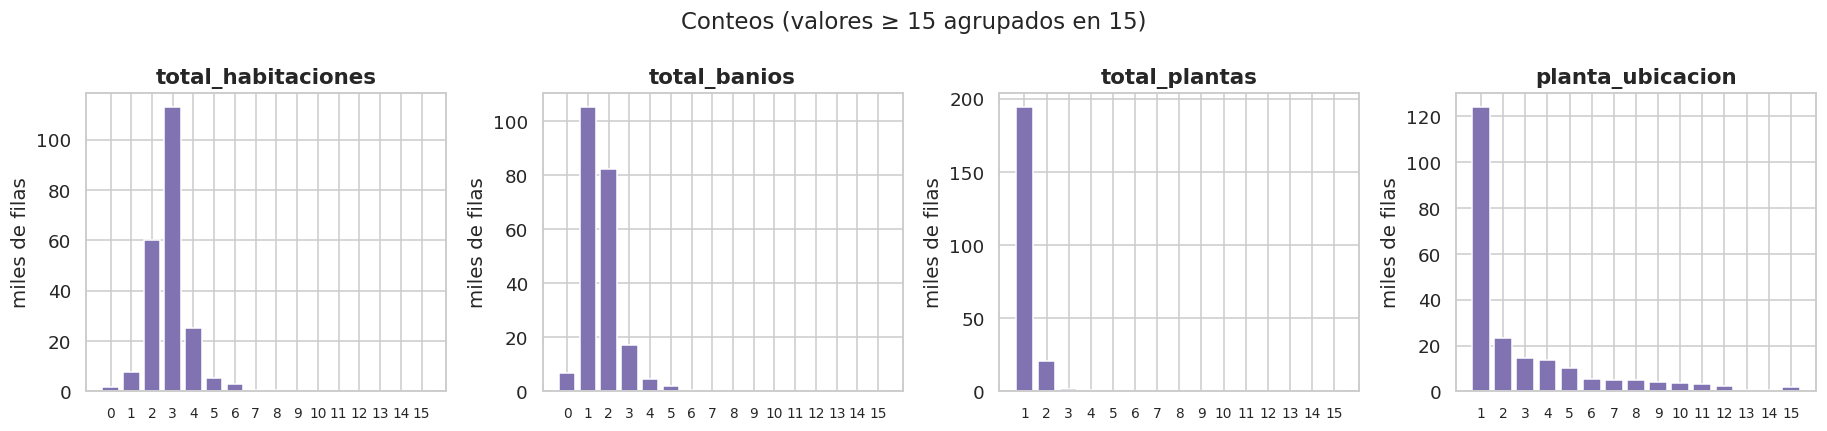

In [10]:
# Figura: diagramas de barras de las variables de conteo. Al ser discretas, las
# barras por valor son más fieles que un histograma con bins arbitrarios.
discretas = [c for c in ["total_habitaciones", "total_banios", "total_plantas", "planta_ubicacion"] if c in train]
fig, axes = plt.subplots(1, len(discretas), figsize=(4.2 * len(discretas), 4))
for ax, c in zip(np.atleast_1d(axes), discretas):
    # clip(upper=15) agrupa la cola larga en la barra "15" para que los valores
    # frecuentes (0–5) sean legibles; value_counts().sort_index() ordena por valor.
    vc = train[c].dropna().astype(int).clip(upper=15).value_counts().sort_index()
    ax.bar(vc.index.astype(str), vc.values / 1000, color="#8172b2")  # eje y en miles
    ax.set_title(c)
    ax.set_ylabel("miles de filas")
    ax.tick_params(axis="x", labelsize=9)
fig.suptitle("Conteos (valores ≥ 15 agrupados en 15)")
fig.tight_layout()
G.guardar(fig, "05_conteos")
plt.show()

## 5.7 Variables categóricas

In [11]:
# Tabla de frecuencias de cada categórica. E.resumen_categorico cuenta cada
# categoría (incluidos los nulos), su % y marca como "rara" la que tiene < 1 %
# de train. Las categorías raras aportan coeficientes inestables en la
# logística (pocas observaciones) y pueden no aparecer en algún fold.
for c in cats:
    t = E.resumen_categorico(train, c)
    print(f"\n=== {c} === ({len(t)} categorías, {int(t['rara (<1%)'].sum())} raras)")
    print(t.head(15).to_string(float_format=lambda v: f"{v:,.2f}"))  # 15 más frecuentes


=== tipo_vivienda === (4 categorías, 0 raras)
               frecuencia     % rara (<1%)
tipo_vivienda                             
tv_4               167404 76.49      False
tv_3                32179 14.70      False
tv_1                15110  6.90      False
tv_2                 4177  1.91      False

=== uso === (6 categorías, 3 raras)
                                              frecuencia     % rara (<1%)
uso                                                                      
Residencial_Vivienda_Hasta_3_Pisos                103961 47.50      False
Residencial_Apartamentos_4_y_mas_pisos_en_PH       93342 42.65      False
Residencial_Vivienda_Hasta_3_Pisos_En_PH           21312  9.74      False
Residencial_Apartamentos_4_y_mas_pisos               246  0.11       True
Residencial_Vivienda_Recreacional_En_PH                8  0.00       True
Residencial_Vivienda_Recreacional                      1  0.00       True

=== condicion_predio === (4 categorías, 1 raras)
                

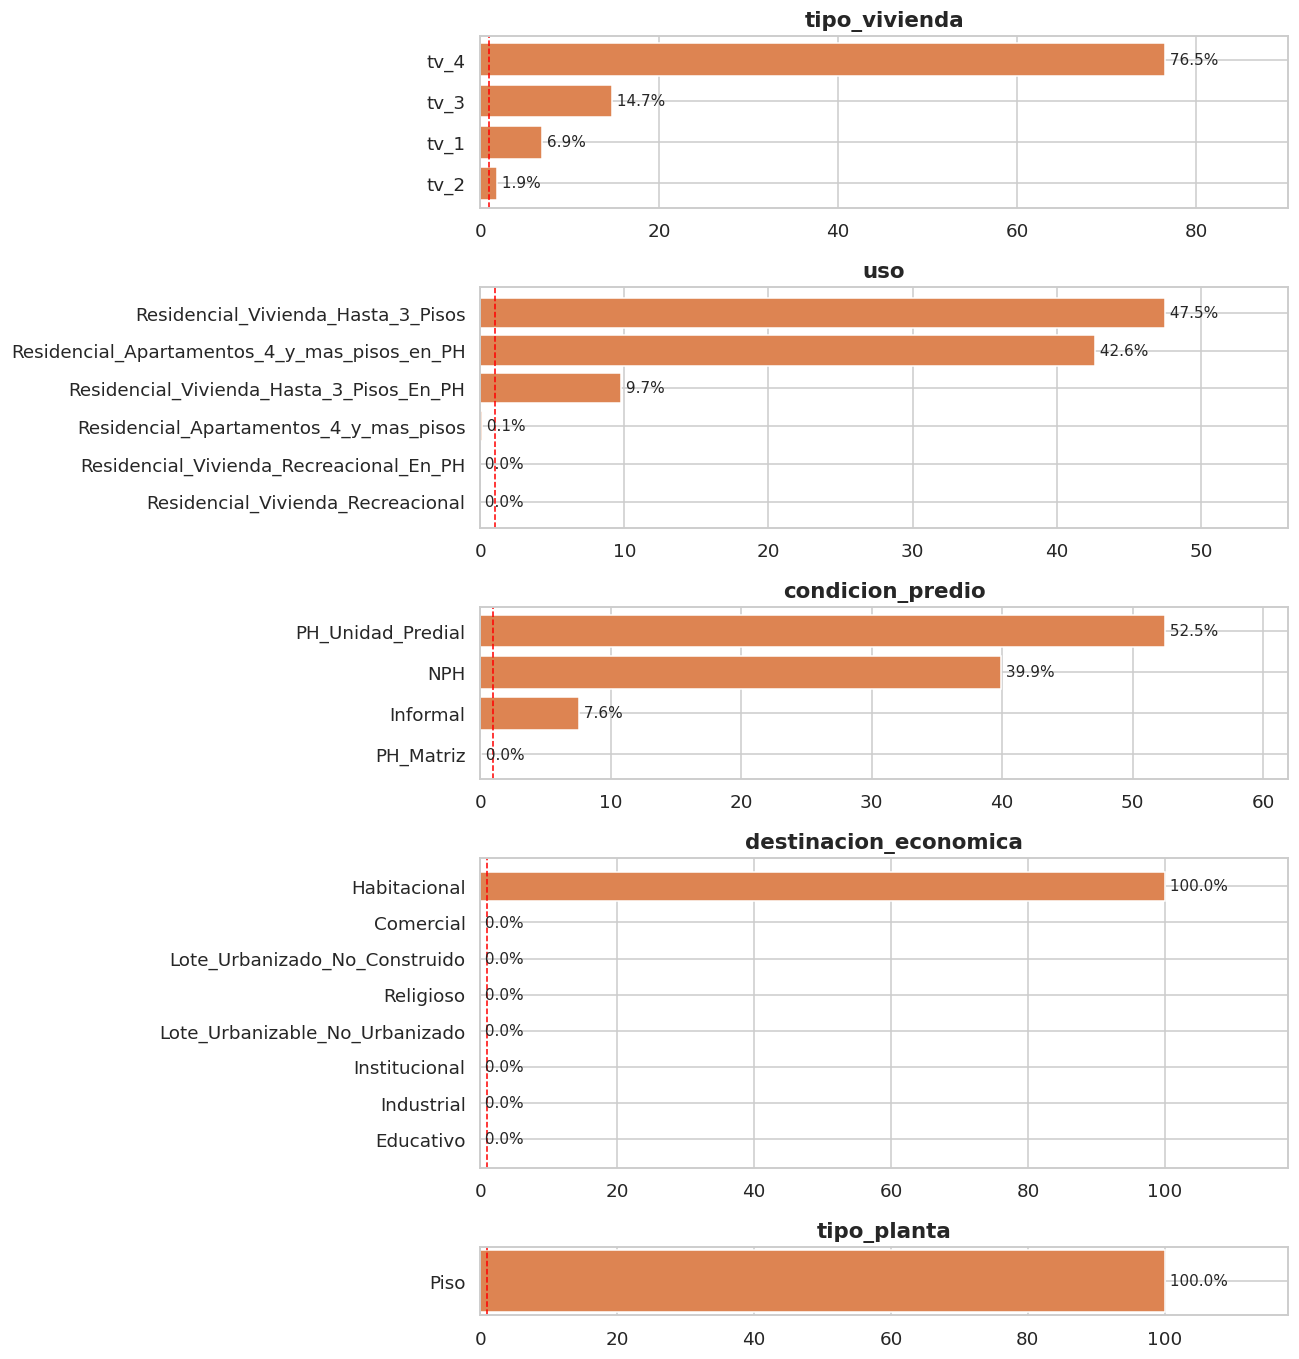

In [12]:
# Figura: barras horizontales con el % de cada categoría (máximo 12 por
# variable). La línea roja discontinua marca el umbral de 1 % que define
# una categoría como rara. La altura de cada panel es proporcional a su
# número de categorías para que todas las barras tengan un grosor similar.
fig, axes = plt.subplots(len(cats), 1, figsize=(12, 2.2 + 0.45 * sum(min(train[c].nunique(), 12) for c in cats)),
                         gridspec_kw={"height_ratios": [min(train[c].nunique(), 12) + 1 for c in cats]})
for ax, c in zip(np.atleast_1d(axes), cats):
    # Los nulos se muestran como "faltante" para que su peso sea visible;
    # [::-1] invierte el orden para que la categoría más frecuente quede arriba.
    vc = train[c].fillna("faltante").value_counts(normalize=True).mul(100).head(12)[::-1]
    ax.barh(vc.index, vc.values, color="#dd8452")
    for i, v in enumerate(vc.values):
        ax.text(v, i, f" {v:.1f}%", va="center", fontsize=10)  # etiqueta del % en cada barra
    ax.axvline(1, color="red", ls="--", lw=1)  # umbral de categoría rara (1 %)
    ax.set_title(c)
    ax.set_xlim(0, vc.max() * 1.18)  # margen a la derecha para que quepan las etiquetas
fig.tight_layout()
G.guardar(fig, "05_categoricas")
plt.show()

```{admonition} Categorías raras, degeneradas y redundantes
:class: note
- **`tipo_vivienda`** (códigos del dominio oficial de ArcGIS): 76.5 % es
  `tv_4` ("No Aplica"), 14.7 % `tv_3` ("No VIS"), 6.9 % `tv_1` (VIS) y
  1.9 % `tv_2` (VIP). Que tres de cada cuatro unidades sean "No Aplica"
  indica que la clasificación VIS/VIP solo se registra para una parte del
  parque (probablemente vivienda nueva de proyectos). Ninguna categoría es
  rara.
- **`uso`**: tres categorías concentran el 99.9 % (vivienda hasta 3 pisos
  47.5 %, apartamentos de 4 y más pisos en PH 42.6 %, vivienda hasta 3 pisos
  en PH 9.7 %); las otras tres (apartamentos sin PH, vivienda recreacional
  con y sin PH) suman 255 filas y se agrupan como `infrequent`.
- **`condicion_predio`**: PH unidad predial 52.5 %, NPH 39.9 %, Informal
  7.6 %; `PH_Matriz` (62 filas) es rara y se agrupa.
- **Variables degeneradas:** `destinacion_economica` es "Habitacional" en el
  **99.99 %** de train (29 filas en otras 7 categorías) y `tipo_planta` es
  **constante** ("Piso" en el 100 %; las otras 2 categorías del crudo
  desaparecen con las exclusiones del embudo del cap. 1, que saca garajes y
  depósitos). Ninguna de las dos puede discriminar el estrato: en el cap. 6
  `destinacion_economica` tiene V de Cramér = 0 (p = 0.47) y `tipo_planta`,
  por ser constante, ni siquiera entra en la prueba. Ambas **se excluyen**
  del modelo (cap. 9).
- **Decisión:** agrupar las categorías con < 1 % (línea roja) en una
  categoría `infrequent` con `OneHotEncoder(min_frequency=0.01)`, que calcula
  las frecuencias **solo en train**.
- Posible **redundancia**: `uso` ("…en_PH") y `condicion_predio` codifican
  ambos el régimen de propiedad horizontal. Su asociación se mide en el cap. 6.
```

In [13]:
# Se registra el umbral de frecuencia mínima para el OneHotEncoder del modelo.
# Al estar dentro del Pipeline, las frecuencias se recalculan en cada fold de
# entrenamiento, así que el agrupamiento de categorías raras no filtra
# información de validación ni de test.
C.guardar_decision("onehot_min_frecuencia", 0.01,
                   "Categorías con < 1 % en train se agrupan en 'infrequent' (cap. 5.7).")

[decisión registrada] onehot_min_frecuencia = 0.01
   motivo: Categorías con < 1 % en train se agrupan en 'infrequent' (cap. 5.7).


## 5.8 Resumen

```{admonition} Interpretación
:class: note
- **Todas las variables físicas son altamente asimétricas** según la tabla
  del profesor Lihki (|asimetría| > 1) y leptocúrticas. Las más extremas son el
  terreno (asimetría 51.7, curtosis 3 402) y el número de plantas (10.2;
  148); el área construida queda en 4.0 (curtosis 34). La unidad típica
  tiene 76 m² construidos, 3 habitaciones y 1 baño, pero la cola llega a
  1 971 m² construidos y a 36 022 m² de terreno. Los máximos de habitaciones
  (20), baños (15) y área construida quedan dentro de los umbrales con que
  el cap. 1 excluye los "registros agregados" (edificios enteros en una fila),
  y el piso máximo (41) dentro del techo de 60.
- `log1p` corrige casi por completo la asimetría de área construida
  (4.0 → 0.42), terreno (51.7 → 0.32), baños (1.7 → 0.01) y antigüedad
  (1.3 → −0.49); en habitaciones (2.3 → −0.67) la sobrecorrige y la deja
  moderada hacia la izquierda; en plantas (10.2 → 4.8) y piso (2.3 → 1.1)
  la mejora es parcial porque son conteos con mucho peso en 1. **Decisión:**
  `log1p` en 7 variables; `altura` queda lineal (log1p empeora su asimetría:
  −10.0 → −16.9).
- `altura` es **casi constante**: vale 3 (metros por planta) en el 99.7 %
  de las filas (su IQR es 0, así que sus 683 outliers de Tukey son
  exactamente los valores distintos de 3). Aportará muy poco (cap. 6:
  η² = 0.005).
- Las pruebas de normalidad rechazan en todas (esperable con n grande); no es
  un problema para la regresión logística, que no supone normalidad de las
  predictoras. La transformación busca reducir la influencia de las colas,
  no "normalizar".
- Las coordenadas (`x_km`, `y_km`, `dist_centro_km`) son aproximadamente
  simétricas; `y_km` es platicúrtica (la ciudad está repartida de forma
  bastante uniforme a lo largo del eje norte-sur).
- Categóricas: pocas categorías dominantes, varias raras que se agrupan, y
  dos variables degeneradas (`destinacion_economica`, `tipo_planta`).
```